In [2]:
import pandas as pd
df=pd.read_csv("DataCoSupplyChainDataset.csv",encoding='ISO-8859-1')

In [3]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [4]:
# Display the first few rows to verify the data load
print("=== First 5 Rows of Supply Chain Dataset ===")
print(df.head())

=== First 5 Rows of Supply Chain Dataset ===
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1  

In [5]:
print("\n=== Missing Values Count ===")
missing_values = df.isnull().sum()
print(missing_values)


=== Missing Values Count ===
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market    

In [6]:
def features_with_missing_values(data):
    x = data.isnull().sum().sum()/(data.shape[0]*data.shape[1])*100
    print('Percentage of Total Missing Values is ' ,round(x,2) ,'%')
    print('Missing Value Estimation :')
    for i in data.columns:
        if data[i].isna().sum()>0:
            print('The Feature ',i,' has '+ str(data[i].isna().sum()) + ' missing values')
            
features_with_missing_values(df)

Percentage of Total Missing Values is  3.51 %
Missing Value Estimation :
The Feature  Customer Lname  has 8 missing values
The Feature  Customer Zipcode  has 3 missing values
The Feature  Order Zipcode  has 155679 missing values
The Feature  Product Description  has 180519 missing values


In [7]:
print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

Dataset rows: 180519
Dataset columns: 53


In [9]:
modeling_columns = ['Type',
                  'Days for shipping (real)', 
                  'Days for shipment (scheduled)',
                  'Benefit per order',
                  'Sales per customer',
                  'Latitude',
                  'Longitude',
                  'Order Item Discount',
                  'Order Item Discount Rate',
                  'Order Item Total',
                  'Order Profit Per Order',
                  'Order Status',
                  'Shipping Mode',
                  'Late_delivery_risk']

In [10]:
len(modeling_columns)

14

In [11]:
def drop_columns(dataset, columns_to_drop):
    dataset = dataset.drop(columns=columns_to_drop)
    print(f"{len(columns_to_drop)} columns dropped successfully. Number of columns remaining: {len(dataset.columns)}")
    return dataset

In [12]:
columns_to_drop = [col for col in df.columns if col not in modeling_columns]

In [13]:
len(columns_to_drop)

39

In [14]:
df1=drop_columns(df,columns_to_drop)

39 columns dropped successfully. Number of columns remaining: 14


In [15]:
print(f"Dataset rows: {df1.shape[0]}")
print(f"Dataset columns: {df1.shape[1]}")

Dataset rows: 180519
Dataset columns: 14


In [16]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [17]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Latitude', 'Longitude', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Total',
       'Order Profit Per Order', 'Order Status', 'Shipping Mode'],
      dtype='object')

In [18]:
# check null values
df1.isna().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Late_delivery_risk               0
Latitude                         0
Longitude                        0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Total                 0
Order Profit Per Order           0
Order Status                     0
Shipping Mode                    0
dtype: int64

In [19]:
#analyze categorical columns 
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df1[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Order Status
Number of unique values: 9

Column: Shipping Mode
Number of unique values: 4


In [20]:
df1.duplicated().sum()

4

In [21]:
df1[df1.duplicated()]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
94789,DEBIT,5,4,53.230000,118.290001,1,28.102118,-82.512115,11.7,0.09,118.290001,53.230000,COMPLETE,Standard Class
137818,PAYMENT,2,4,138.589996,395.980011,0,21.287289,-157.671402,4.0,0.01,395.980011,138.589996,PENDING_PAYMENT,Standard Class
146875,DEBIT,2,2,93.599998,359.980011,0,29.780575,-95.171997,40.0,0.10,359.980011,93.599998,COMPLETE,Second Class
175279,DEBIT,2,1,120.949997,335.980011,1,18.380119,-66.183128,64.0,0.16,335.980011,120.949997,COMPLETE,First Class


In [22]:
df1=df1.drop_duplicates()

In [23]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [24]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Type','Order Status', 'Shipping Mode']
le = LabelEncoder()
for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])

C:\Users\cstd\AppData\Local\Temp\ipykernel_10748\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = le.fit_transform(df1[col])
C:\Users\cstd\AppData\Local\Temp\ipykernel_10748\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = le.fit_transform(df1[col])
C:\Users\cstd\AppData\Local\Temp\ipykernel_10748\2977665707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

In [25]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [26]:
X = df1.drop(columns=['Late_delivery_risk'])  # features
y = df1['Late_delivery_risk']                 # target

In [27]:
X

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [28]:
y

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 180515, dtype: int64

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
X_scaled

array([[0.33333333, 0.5       , 1.        , ..., 0.84179973, 0.25      ,
        1.        ],
       [1.        , 0.83333333, 1.        , ..., 0.77618291, 0.625     ,
        1.        ],
       [0.        , 0.66666667, 1.        , ..., 0.77643548, 0.125     ,
        1.        ],
       ...,
       [1.        , 0.83333333, 1.        , ..., 0.85141263, 0.625     ,
        1.        ],
       [0.66666667, 0.5       , 1.        , ..., 0.86011167, 0.75      ,
        1.        ],
       [0.66666667, 0.66666667, 1.        , ..., 0.85678012, 0.75      ,
        1.        ]])

In [32]:
X_scaled.shape

(180515, 13)

In [35]:
import numpy as np
X_3D = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [36]:
X_3D.shape 

(180515, 1, 13)

In [37]:
X.shape[1]

13

In [42]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, GlobalAveragePooling1D, Dense, ReLU

def feature_extraction(input_shape):
    inputs = Input(shape=input_shape)

    # First Conv Block
    x = Conv1D(filters=32, kernel_size=3, padding='same')(inputs)
    x = ReLU()(x)
    x = BatchNormalization()(x)

    # Second Conv Block
    x = Conv1D(filters=64, kernel_size=3, padding='same')(x)
    x = ReLU()(x)
    x = BatchNormalization()(x)

    # Third Conv Block
    x = Conv1D(filters=96, kernel_size=3, padding='same')(x)
    x = ReLU()(x)
    x = BatchNormalization()(x)

    # Global Pooling
    x = GlobalAveragePooling1D()(x)

    # Fully Connected Layer
    x = Dense(128, activation='relu')(x)

    model = Model(inputs=inputs, outputs=x)
    return model


In [43]:
input_shape = (1, X.shape[1])
model=feature_extraction(input_shape)

In [44]:
model

In [45]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [46]:
X_features = model.predict(X_3D)
print(X_features.shape) 

5642/5642 [==============================] - 7s 1ms/step
(180515, 128)


In [47]:
X_features

array([[0.02397408, 0.01480459, 0.00751015, ..., 0.        , 0.        ,
        0.00417385],
       [0.01598696, 0.01337931, 0.01265396, ..., 0.        , 0.        ,
        0.        ],
       [0.02370933, 0.01504673, 0.00241964, ..., 0.        , 0.        ,
        0.00603079],
       ...,
       [0.01793005, 0.01710407, 0.01171215, ..., 0.        , 0.        ,
        0.        ],
       [0.01757895, 0.01696541, 0.00978376, ..., 0.        , 0.        ,
        0.00106789],
       [0.01544011, 0.0155336 , 0.00799414, ..., 0.        , 0.        ,
        0.00052119]], dtype=float32)

In [48]:
y.shape

(180515,)

In [50]:
#np.save("1D_CNN_32_128",X_features)

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_remaining ,y_train ,y_remaining=train_test_split(X_features,y,test_size=0.4,random_state=42)

#spliting the remaining data into testing and validation 

X_val,X_test,y_val,y_test=train_test_split(X_remaining ,y_remaining , test_size=0.5,random_state=42)

In [52]:
X_train.shape, X_val.shape ,X_test.shape , y_train.shape, y_val.shape ,y_test.shape 

((108309, 128), (36103, 128), (36103, 128), (108309,), (36103,), (36103,))

In [53]:
X_train.shape, X_test.shape,X_val.shape

((108309, 128), (36103, 128), (36103, 128))

In [54]:
#softmax regression

In [55]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
softmax_model=LogisticRegression(max_iter=1000 , multi_class='multinomial')
history=softmax_model.fit(X_train , y_train)

C:\Users\cstd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [63]:
y_pred=softmax_model.predict(X_test)
y_pred

array([0, 1, 1, ..., 0, 1, 1], dtype=int64)

In [64]:
accuracy=accuracy_score(y_test,y_pred)
print("testing accuracy:",accuracy*100)

testing accuracy: 89.1227875799795


In [65]:
y_pred_training=softmax_model.predict(X_train)

In [66]:
y_pred_training

array([1, 0, 1, ..., 0, 1, 0], dtype=int64)

In [67]:
accuracy=accuracy_score(y_train,y_pred_training)
print("training accuracy:",accuracy*100)

training accuracy: 89.2363515497327


In [68]:
y_pred_val=softmax_model.predict(X_val)

In [69]:
y_pred_val

array([1, 0, 1, ..., 1, 0, 0], dtype=int64)

In [70]:
val_accuracy=accuracy_score(y_val,y_pred_val)
print("validation accuracy:",val_accuracy*100)

validation accuracy: 89.3166772844362


In [71]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88     16393
           1       0.88      0.93      0.90     19710

    accuracy                           0.89     36103
   macro avg       0.89      0.89      0.89     36103
weighted avg       0.89      0.89      0.89     36103



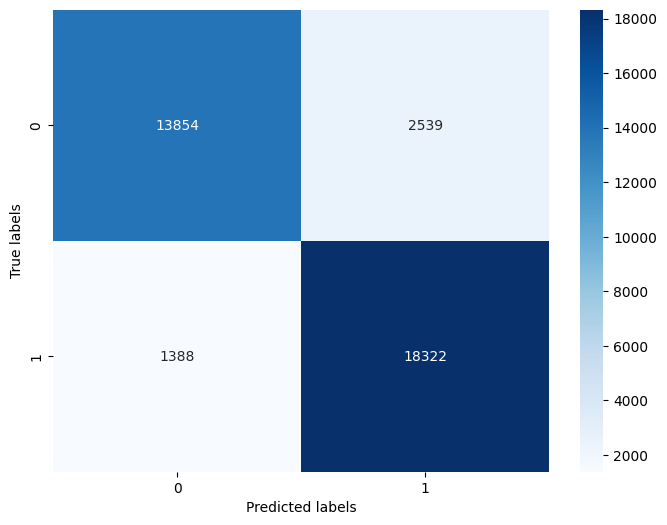

In [72]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

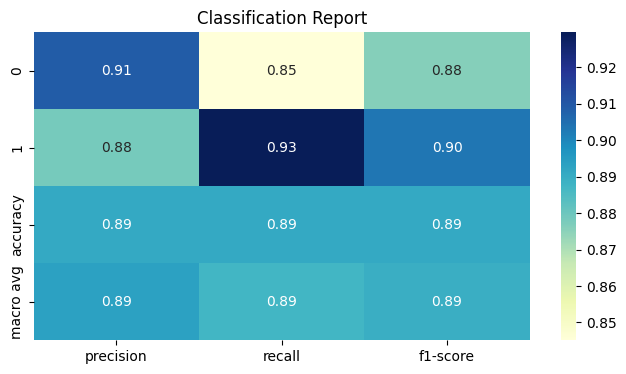

In [73]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

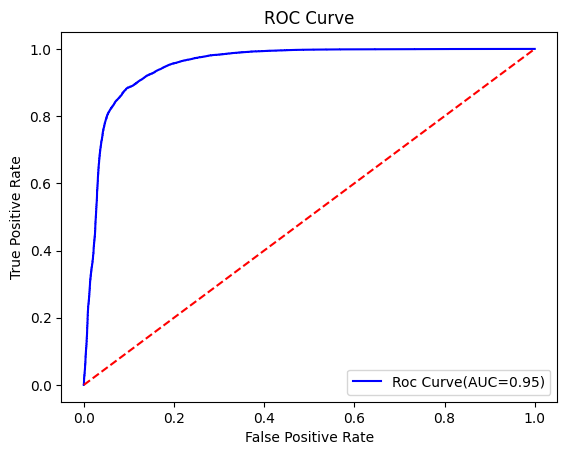

AUC Score: 0.9536320476594013


In [74]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=softmax_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

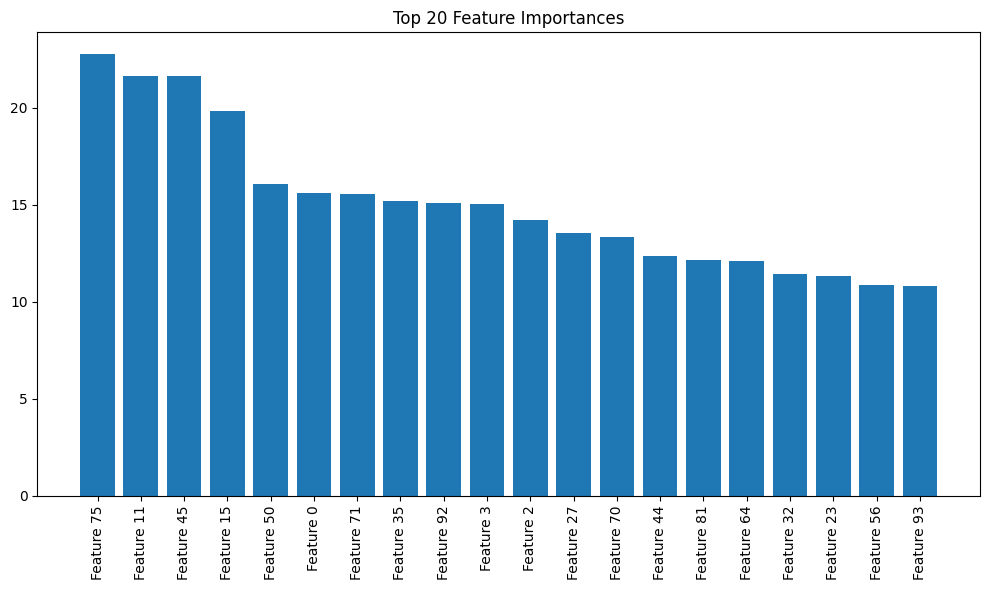

In [75]:
import numpy as np
import matplotlib.pyplot as plt

coefficients = softmax_model.coef_[0]  # For binary classification
feature_indices = np.argsort(np.abs(coefficients))[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(20), np.abs(coefficients[feature_indices[:20]]))
plt.xticks(range(20), [f'Feature {i}' for i in feature_indices[:20]], rotation=90)
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()


In [77]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [78]:
tn,fp,fn,tp=cm.ravel()

In [79]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [80]:
tn,fp,fn,tp

(13854, 2539, 1388, 18322)

In [81]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.7809354604667103,
 0.7792998714108862,
 0.8782896313695413,
 0.9295788939624556,
 0.9032067240146903,
 0.15488318184590985,
 0.0704211060375444)

In [82]:
#rf

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # features_train from LSTM on training set

# Predict on test features
y_pred = rf.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 0.998864360302468


In [84]:
y_pred_train = rf.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 1.0


In [85]:
y_pred_val = rf.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 0.998615073539595


In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16393
           1       1.00      1.00      1.00     19710

    accuracy                           1.00     36103
   macro avg       1.00      1.00      1.00     36103
weighted avg       1.00      1.00      1.00     36103



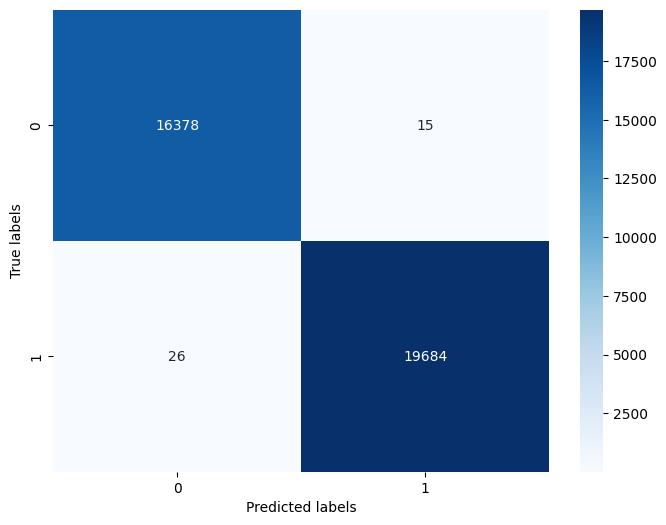

In [87]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

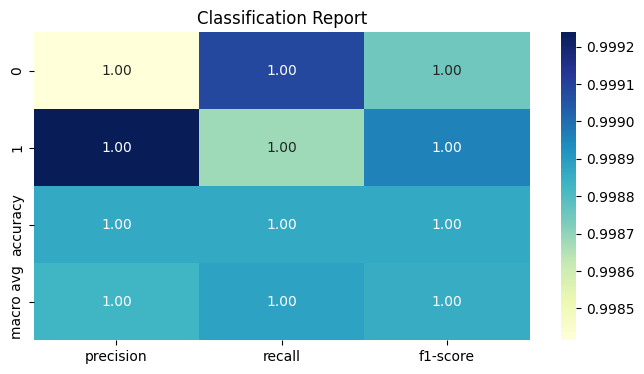

In [88]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [90]:
X_fe=X_features.reshape(X_features.shape[0],-1)

In [91]:
X_fe.shape ,y.shape 

((180515, 128), (180515,))

In [92]:
#5fold cross validation for rf
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    rf.fit(X_tr,y_tr)
    y_pred=rf.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')



Fold1:Accuracy=0.9990
Fold2:Accuracy=0.9993
Fold3:Accuracy=0.9991
Fold4:Accuracy=0.9989
Fold5:Accuracy=0.9989
Average Accuracy:0.9990


In [93]:
#After Five Folding cross validation
y_pred_train = rf.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9996399191202947


In [94]:
y_pred = rf.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [95]:
y_pred_val = rf.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


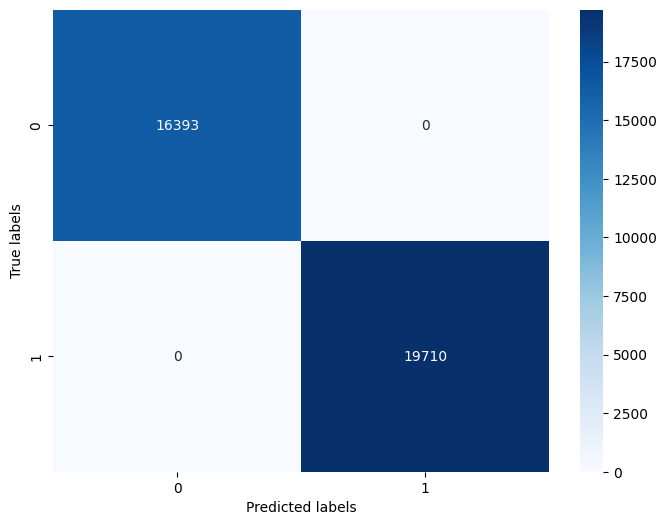

In [96]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

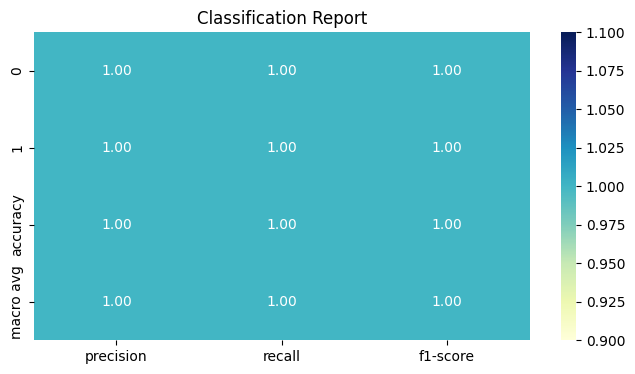

In [97]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

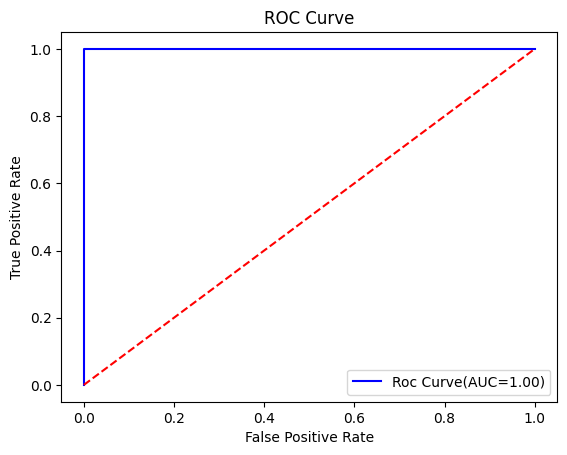

AUC Score: 1.0


In [98]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=rf.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

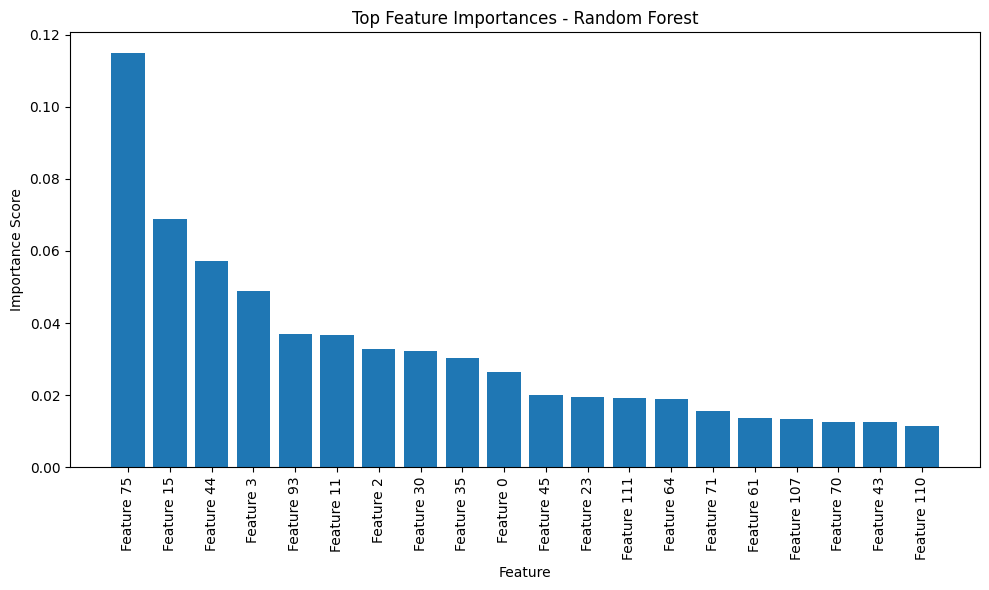

In [99]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = rf.feature_importances_  # assuming rf_model is your trained model

# Sort the feature importances
indices = np.argsort(importances)[::-1]

# Plot top N features (e.g., top 20)
plt.figure(figsize=(10, 6))
plt.title("Top Feature Importances - Random Forest")
plt.bar(range(20), importances[indices[:20]], align='center')
plt.xticks(range(20), [f'Feature {i}' for i in indices[:20]], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


In [87]:
'''import shap

explainer = shap.Explainer(rf.predict, X_train)
shap_values = explainer(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test, plot_type='bar')
'''

"import shap\n\nexplainer = shap.Explainer(rf.predict, X_train)\nshap_values = explainer(X_test)\n\n# Plot summary\nshap.summary_plot(shap_values, X_test, plot_type='bar')\n"

In [100]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [101]:
tn,fp,fn,tp=cm.ravel()

In [102]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [103]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [104]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [105]:
#svm

In [106]:
from sklearn.svm import SVC
svm_model=SVC(kernel='rbf', random_state=42,probability=True)
svm_model.fit(X_train,y_train)

SVC(probability=True, random_state=42)

In [110]:
y_pred=svm_model.predict(X_test)

In [111]:
y_pred

array([0, 1, 1, ..., 0, 1, 1], dtype=int64)

In [112]:
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9858737501038695


In [109]:
y_pred_train=svm_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.986464652060309


In [114]:
y_pred_val=svm_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9864277206880314


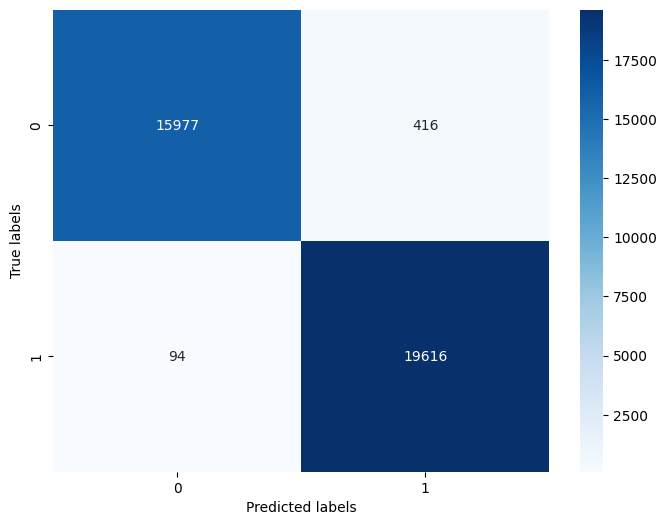

In [116]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

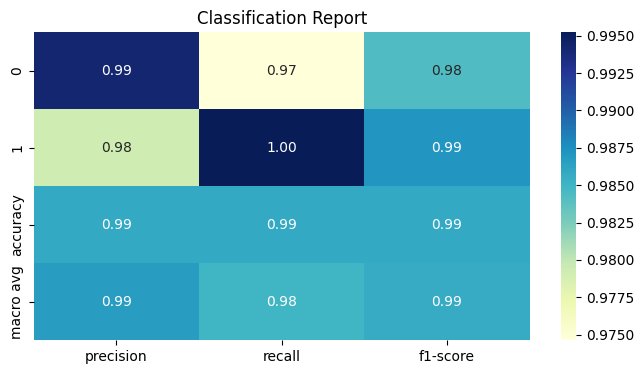

In [117]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

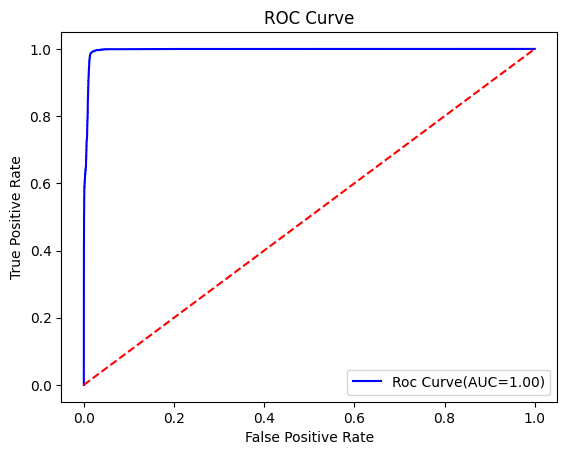

AUC Score: 0.9963130059813491


In [118]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=svm_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [119]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [120]:
tn,fp,fn,tp=cm.ravel()

In [121]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [122]:
tn,fp,fn,tp

(15977, 416, 94, 19616)

In [123]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9716175689149409,
 0.9714598130036665,
 0.9792332268370607,
 0.9952308472856418,
 0.9871672286246288,
 0.025376685170499604,
 0.004769152714358194)

In [124]:
#KNN

In [125]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [126]:
y_pred=knn_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9968700661994848


In [127]:
y_pred_train=knn_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.998338088247514


In [128]:
y_pred_val=knn_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9968423676702767


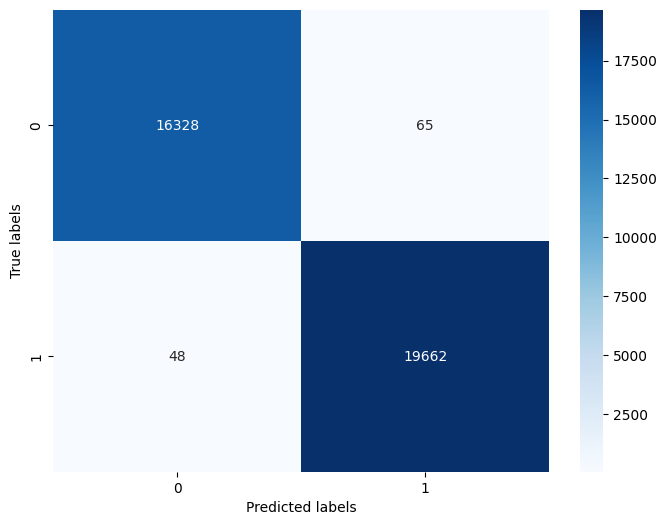

In [132]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

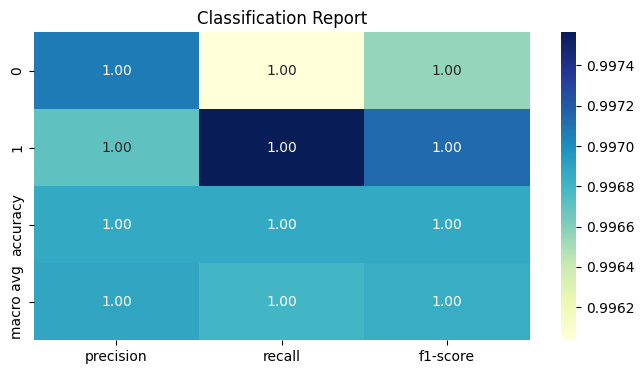

In [131]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

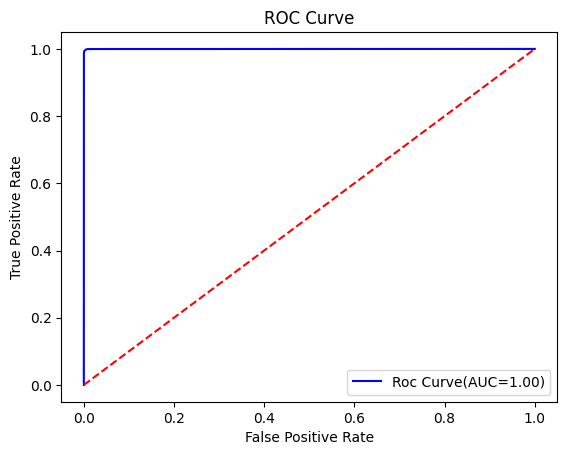

AUC Score: 0.9997279762931073


In [133]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=knn_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [134]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [135]:
tn,fp,fn,tp=cm.ravel()

In [136]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [137]:
tn,fp,fn,tp

(16328, 65, 48, 19662)

In [138]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9936867390668628,
 0.9936862908071575,
 0.9967050235717545,
 0.9975646879756469,
 0.997134670487106,
 0.003965107057890563,
 0.0024353120243531205)

In [139]:
#Random trees

In [140]:
from sklearn.ensemble import ExtraTreesClassifier 

et_model=ExtraTreesClassifier(n_estimators=100,random_state=42)

In [141]:
et_model.fit(X_train,y_train)

ExtraTreesClassifier(random_state=42)

In [142]:
y_pred=et_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9992244411821732


In [143]:
y_pred_train=et_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 1.0


In [144]:
y_pred_val=et_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.998864360302468


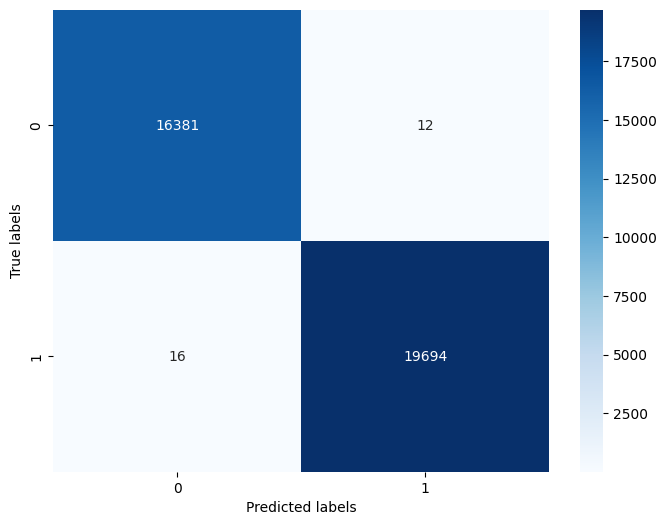

In [145]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

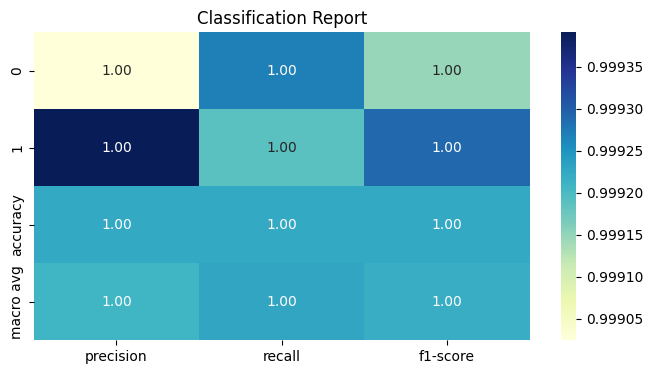

In [146]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [147]:
#5fold cross validation for rf
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    et_model.fit(X_tr,y_tr)
    y_pred=et_model.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')



Fold1:Accuracy=0.9994
Fold2:Accuracy=0.9991
Fold3:Accuracy=0.9993
Fold4:Accuracy=0.9989
Fold5:Accuracy=0.9992
Average Accuracy:0.9992


In [148]:
#After Five Folding cross validation
y_pred_train = et_model.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9997414803940577


In [149]:
y_pred = et_model.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [150]:
y_pred_val = et_model.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


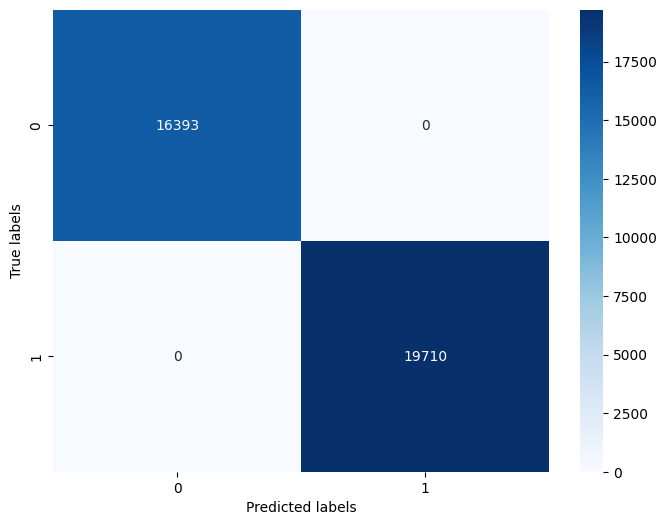

In [151]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

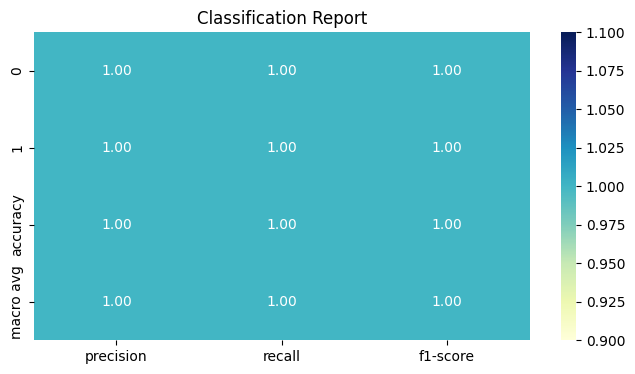

In [152]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

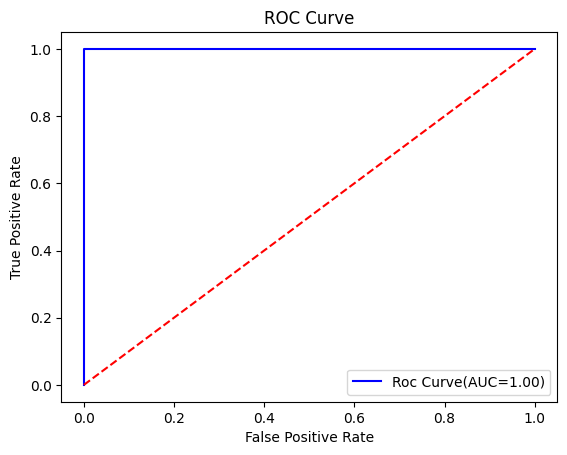

AUC Score: 1.0


In [153]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=et_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

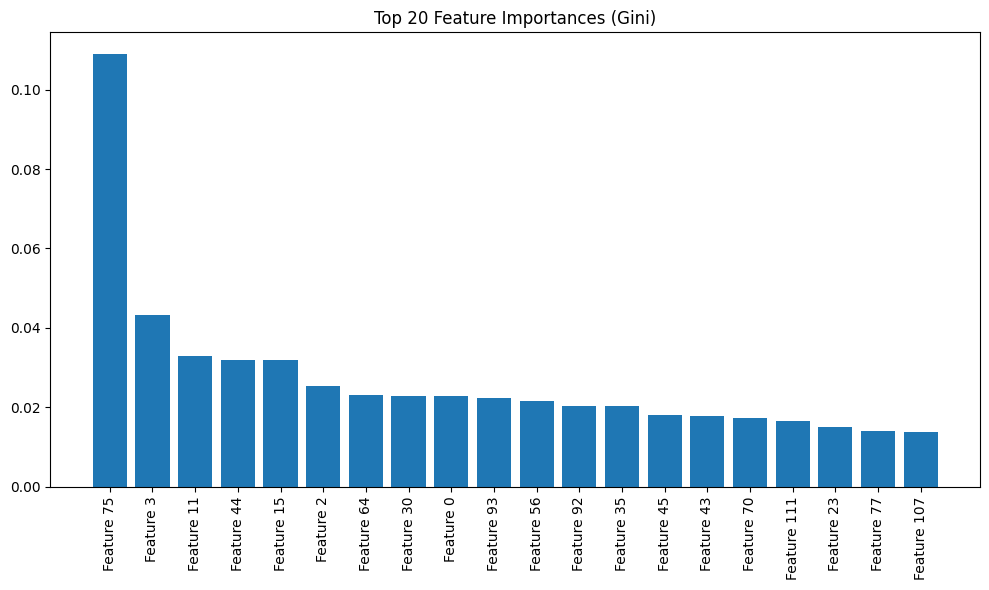

In [154]:
import matplotlib.pyplot as plt
import numpy as np

# Random should be trained already
importances = et_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (Gini)")
plt.bar(range(20), importances[indices[:20]], align='center')
plt.xticks(range(20), [f"Feature {i}" for i in indices[:20]], rotation=90)
plt.tight_layout()
plt.show()


In [155]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [157]:
tn,fp,fn,tp=cm.ravel()

In [158]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [159]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [160]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [161]:
#decision tree

In [162]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)

In [163]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [164]:
y_pred=dt_model.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9913857574162812


In [165]:
y_pred_train=dt_model.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 1.0


In [166]:
y_pred_val=dt_model.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9911364706534083


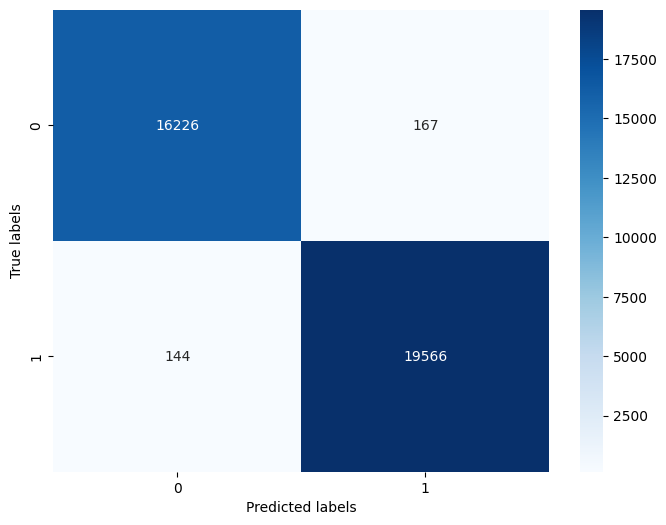

In [167]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

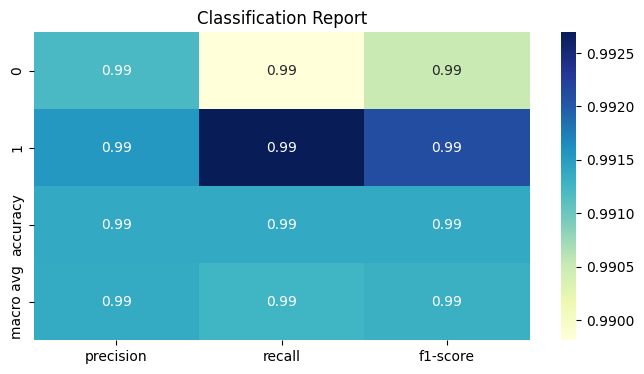

In [168]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [169]:
#5fold cross validation for rf
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
accuracy_list=[]

for train_index,test_index in kf.split(X_fe):
    X_tr,X_te=X_fe[train_index],X_fe[test_index]
    y_tr,y_te=np.array(y)[train_index],np.array(y)[test_index]
    dt_model.fit(X_tr,y_tr)
    y_pred=dt_model.predict(X_te)
    accuracy=accuracy_score(y_te,y_pred)
    accuracy_list.append(accuracy)

for i,accuracy in enumerate(accuracy_list):
    print(f'Fold{i+1}:Accuracy={accuracy:.4f}')

print(f'Average Accuracy:{np.mean(accuracy_list):.4f}')


Fold1:Accuracy=0.9925
Fold2:Accuracy=0.9930
Fold3:Accuracy=0.9925
Fold4:Accuracy=0.9925
Fold5:Accuracy=0.9923
Average Accuracy:0.9926


In [170]:
#After Five Folding cross validation
y_pred_train = dt_model.predict(X_train)

# Evaluate
print("training Accuracy:", accuracy_score(y_train, y_pred_train))

training Accuracy: 0.9974240367836468


In [171]:
y_pred = dt_model.predict(X_test)

# Evaluate
print("testing Accuracy:", accuracy_score(y_test, y_pred))

testing Accuracy: 1.0


In [172]:
y_pred_val = dt_model.predict(X_val)

# Evaluate
print("validation Accuracy:", accuracy_score(y_val, y_pred_val))

validation Accuracy: 1.0


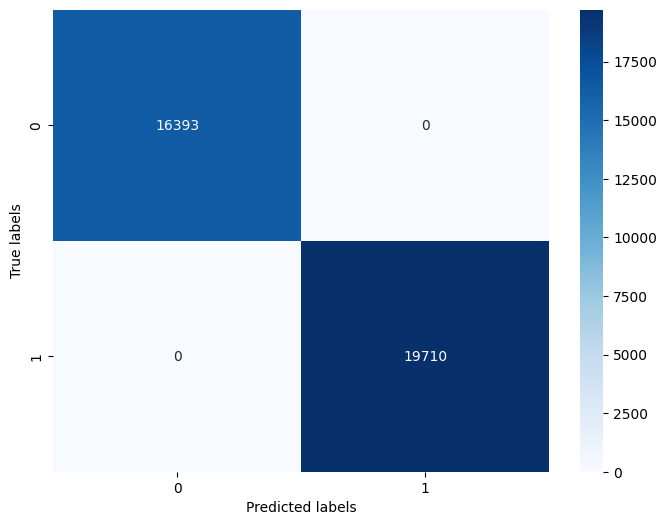

In [173]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

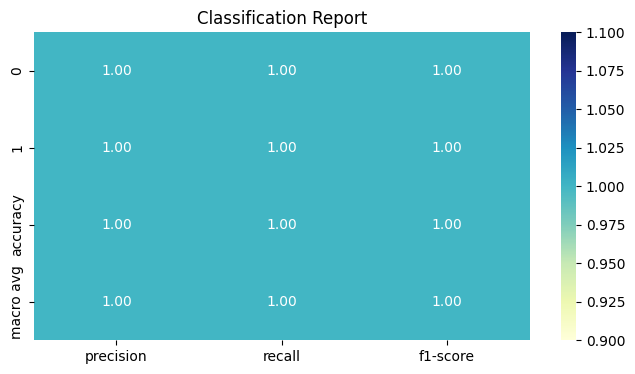

In [174]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

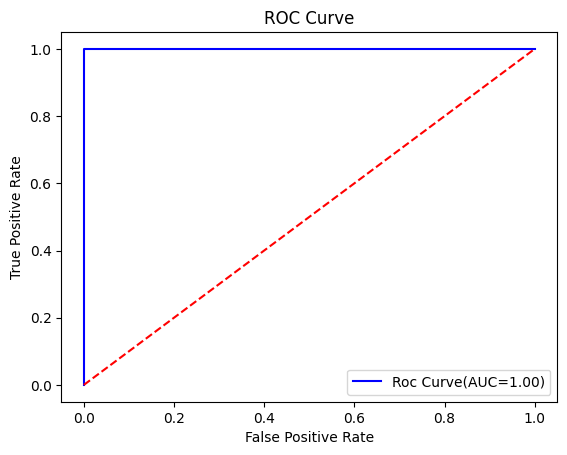

AUC Score: 1.0


In [175]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=dt_model.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [176]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [177]:
tn,fp,fn,tp=cm.ravel()

In [178]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [179]:
tn,fp,fn,tp

(16393, 0, 0, 19710)

In [180]:
mcc,kappa,precision,recall,f1,fpr,fnr

(1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0)

In [181]:
#mlp

In [182]:
from sklearn.neural_network import MLPClassifier
mlp=MLPClassifier(hidden_layer_sizes=(50,50),max_iter=1000,random_state=42)

In [183]:
mlp.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)

In [184]:
y_pred=mlp.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9998061102955433


In [185]:
y_pred_train=mlp.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.9998799730400982


In [186]:
y_pred_val=mlp.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.999750713237127


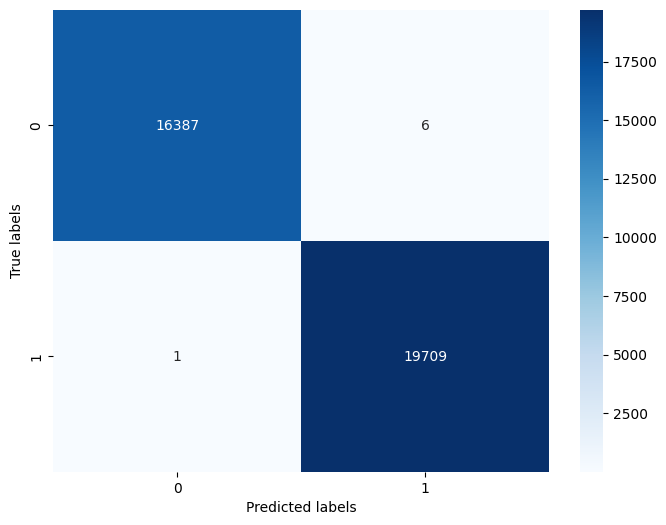

In [187]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

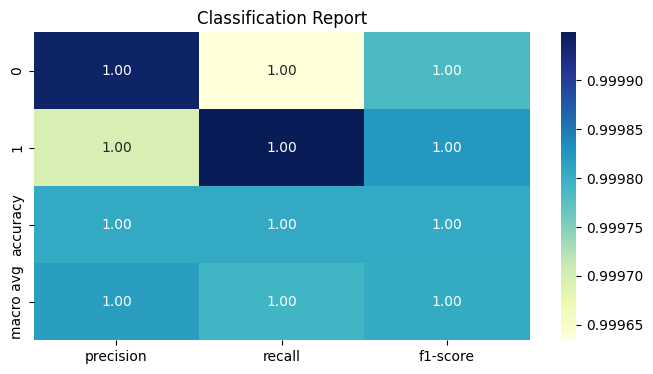

In [188]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

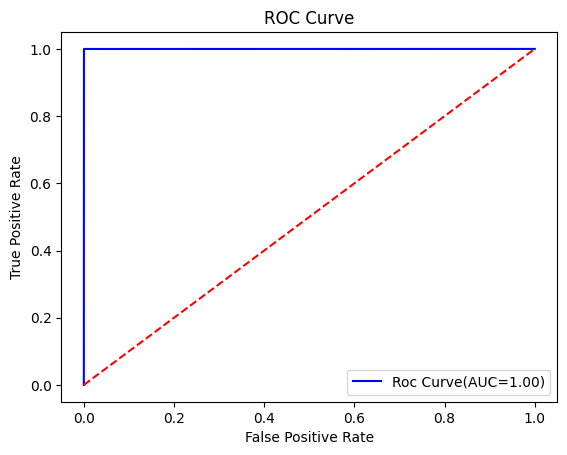

AUC Score: 0.999999551230907


In [189]:
from sklearn.metrics import roc_curve,auc,roc_auc_score 
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=mlp.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [190]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [191]:
tn,fp,fn,tp=cm.ravel()

In [192]:
tn,fp,fn,tp

(16387, 6, 1, 19709)

In [193]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [194]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9996089483659948,
 0.9996089093629138,
 0.9996956632006087,
 0.9999492643328259,
 0.9998224476854788,
 0.0003660098822668212,
 5.073566717402334e-05)

In [195]:
#ROC

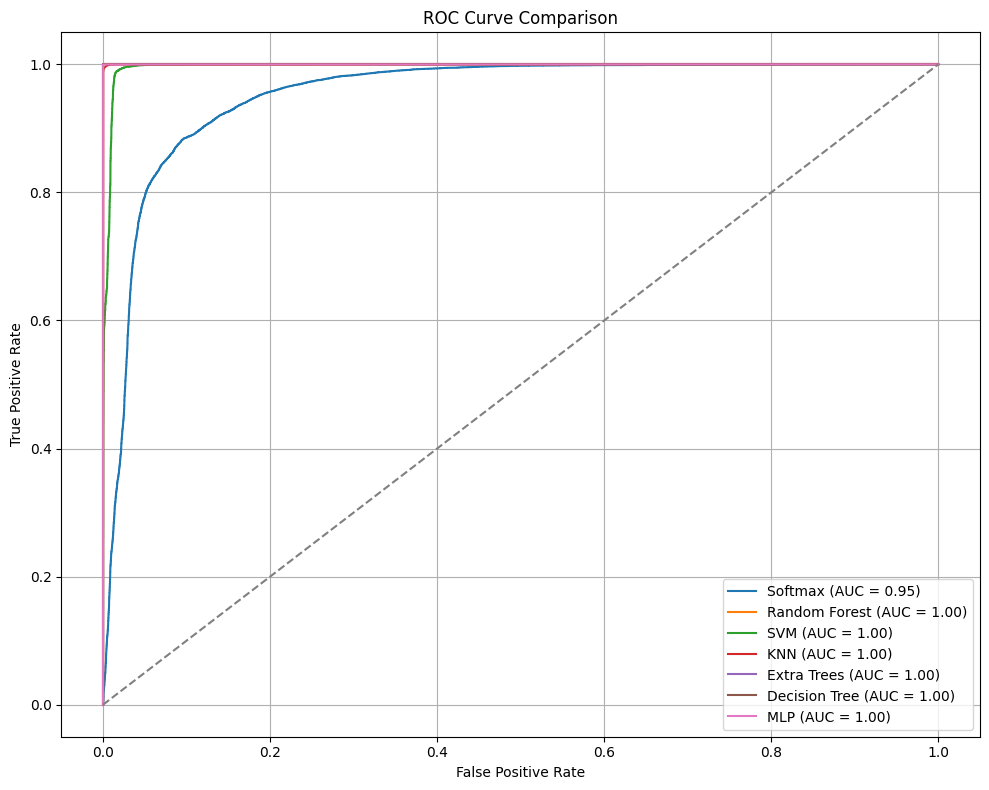

In [196]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {
    "Softmax": softmax_model,
    "Random Forest": rf,
    "SVM": svm_model,
    "KNN": knn_model,
    "Extra Trees": et_model,
    "Decision Tree": dt_model,
    "MLP": mlp
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Get predicted probabilities
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]  # Probability for class 1
    elif hasattr(model, "decision_function"):
        # For some SVMs
        y_proba = model.decision_function(X_test)
    else:
        print(f"Model {name} does not support probability prediction.")
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random baseline
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()


In [203]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def get_feature_importance(model, X_test, y_test, model_name):
    if model_name == 'Logistic Regression':
        return np.abs(model.coef_[0])

    elif model_name in ['Random Forest', 'Extra Trees', 'Decision Tree']:
        return model.feature_importances_

    elif model_name == 'SVM':
        if hasattr(model, 'coef_'):
            return np.abs(model.coef_[0])
        else:
            return None  # For non-linear SVMs

    elif model_name in ['KNN', 'MLP']:
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        return result.importances_mean

    return None


In [204]:
def plot_feature_importances(models_dict, X_test, y_test, top_n=20):
    plt.figure(figsize=(20, 15))

    for idx, (name, model) in enumerate(models_dict.items()):
        importance = get_feature_importance(model, X_test, y_test, name)
        if importance is not None:
            indices = np.argsort(importance)[-top_n:][::-1]
            plt.subplot(3, 3, idx + 1)
            plt.bar(range(top_n), importance[indices])
            plt.xticks(range(top_n), [f'F{i}' for i in indices], rotation=90)
            plt.title(f'{name}')
        else:
            print(f"⚠️ Feature importance not available for: {name}")

    plt.tight_layout()
    plt.show()


⚠️ Feature importance not available for: SVM


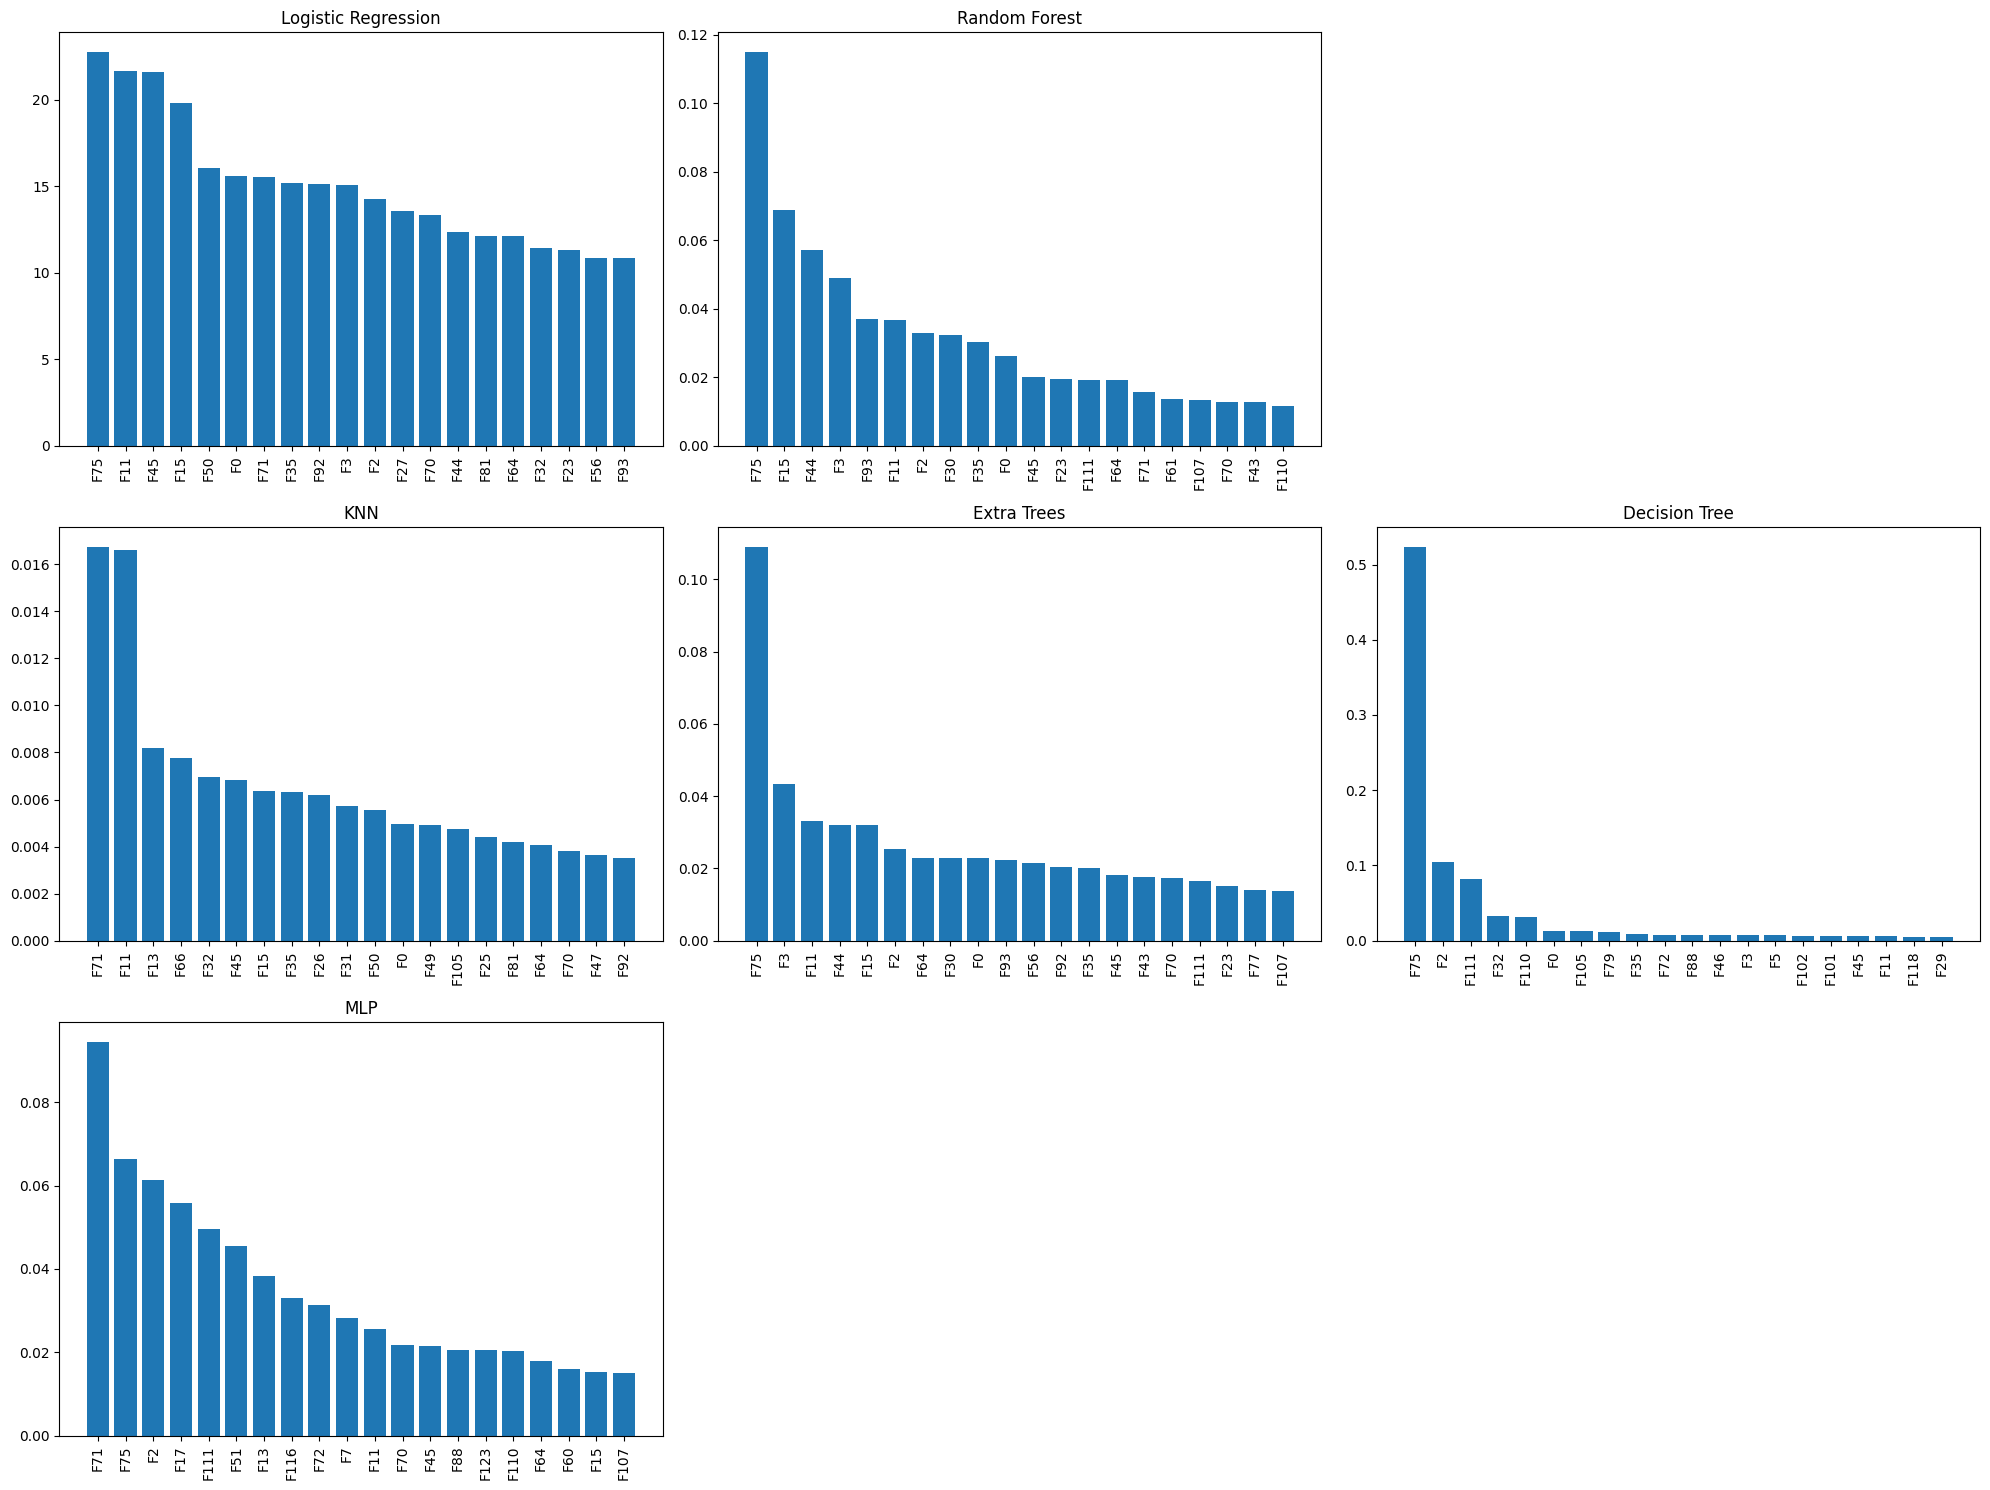

In [205]:
models = {
    'Logistic Regression': softmax_model,
    'Random Forest': rf,
    'SVM': svm_model,
    'KNN': knn_model,
    'Extra Trees': et_model,
    'Decision Tree': dt_model,
    'MLP': mlp
}

plot_feature_importances(models, X_test, y_test)
